In [1]:
import sys
print(sys.executable)

c:\Users\VICTUS\AppData\Local\Programs\Python\Python310\python.exe


In [2]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [4]:
import sys
print(sys.version)

3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Load data
df = pd.read_csv('PreProcessed_IBM_Telco_Customer_Churn_Cleaned.csv')
print(df.shape)
df.head()

(7043, 23)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-1 Year,1
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,2-4 Years,3
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-1 Year,3
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,2-4 Years,3
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-1 Year,1


In [6]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices']


In [8]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [9]:
df = pd.get_dummies(df, columns=['gender'], drop_first=False)
df['gender_Female'] = df['gender_Female'].astype(int)
df['gender_Male'] = df['gender_Male'].astype(int)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df[['gender_Female', 'gender_Male'] + binary_cols].head()

,gender_Female,gender_Male,Partner,Dependents,PhoneService,PaperlessBilling
0,1,0,1,0,0,1
1,0,1,0,0,1,0
2,0,1,0,0,1,1
3,0,1,0,0,0,0
4,1,0,0,0,1,1


In [10]:
pd.set_option('display.max_rows', 30)
df.head(30)

,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,TotalServices,gender_Female,gender_Male
0,7590-VHVEG,0,1,0,1,0,No phone service,DSL,No,Yes,...,Month-to-month,1,Electronic check,29.85,29.85,0,0-1 Year,1,1,0
1,5575-GNVDE,0,0,0,34,1,No,DSL,Yes,No,...,One year,0,Mailed check,56.95,1889.50,0,2-4 Years,3,0,1
2,3668-QPYBK,0,0,0,2,1,No,DSL,Yes,Yes,...,Month-to-month,1,Mailed check,53.85,108.15,1,0-1 Year,3,0,1
3,7795-CFOCW,0,0,0,45,0,No phone service,DSL,Yes,No,...,One year,0,Bank transfer (automatic),42.30,1840.75,0,2-4 Years,3,0,1
4,9237-HQITU,0,0,0,2,1,No,Fiber optic,No,No,...,Month-to-month,1,Electronic check,70.70,151.65,1,0-1 Year,1,1,0
5,9305-CDSKC,0,0,0,8,1,Yes,Fiber optic,No,No,...,Month-to-month,1,Electronic check,99.65,820.50,1,0-1 Year,5,1,0
6,1452-KIOVK,0,0,1,22,1,Yes,Fiber optic,No,Yes,...,Month-to-month,1,Credit card (automatic),89.10,1949.40,0,1-2 Years,4,0,1
7,6713-OKOMC,0,0,0,10,0,No phone service,DSL,Yes,No,...,Month-to-month,0,Mailed check,29.75,301.90,0,0-1 Year,1,1,0
8,7892-POOKP,0,1,0,28,1,Yes,Fiber optic,No,No,...,Month-to-month,1,Electronic check,104.80,3046.05,1,2-4 Years,6,1,0
9,6388-TABGU,0,0,1,62,1,No,DSL,Yes,Yes,...,One year,0,Bank transfer (automatic),56.15,3487.95,0,4-6 Years,3,0,1


In [11]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(df.shape)
df.head()

(7043, 35)


,customerID,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [12]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.dtypes

customerID                               object
SeniorCitizen                             int64
Partner                                   int64
Dependents                                int64
tenure                                    int64
                                          ...  
Contract_One year                         int64
Contract_Two year                         int64
PaymentMethod_Credit card (automatic)     int64
PaymentMethod_Electronic check            int64
PaymentMethod_Mailed check                int64
Length: 35, dtype: object

In [13]:
# Force-check and drop customerID and TenureGroup if they still exist
print("Before:", df.columns.tolist())

cols_to_drop = [c for c in ['customerID', 'TenureGroup'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

print("After:", df.columns.tolist())
print("customerID present?", 'customerID' in df.columns)

Before: ['customerID', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup', 'TotalServices', 'gender_Female', 'gender_Male', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
After: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'gender_Female', 'gen

In [14]:

X = df.drop(columns=['Churn'])
y = df['Churn']
print(X.dtypes.value_counts())
print(X.select_dtypes(include='object').columns.tolist())  # must be []

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

int64      30
float64     2
Name: count, dtype: int64
[]
Scaled train shape: (5634, 32)
Scaled test shape: (1409, 32)


In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


In [16]:
from tensorflow.keras.layers import Input

def build_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model(X_train_scaled.shape[1])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6976 - auc: 0.7682 - loss: 0.5778 - val_accuracy: 0.7232 - val_auc: 0.8111 - val_loss: 0.5400
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7411 - auc: 0.8247 - loss: 0.5168 - val_accuracy: 0.7232 - val_auc: 0.8189 - val_loss: 0.5236
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7542 - auc: 0.8337 - loss: 0.5038 - val_accuracy: 0.7045 - val_auc: 0.8221 - val_loss: 0.5527
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7557 - auc: 0.8405 - loss: 0.4943 - val_accuracy: 0.7063 - val_auc: 0.8244 - val_loss: 0.5474
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7544 - auc: 0.8420 - loss: 0.4893 - val_accuracy: 0.7161 - val_auc: 0.8243 - val_loss: 0.5214
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7559 - auc: 0.8428 - loss: 0.4902 - val_accuracy: 0.7196 - val_auc: 0.8261 - val_loss: 0.5149
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

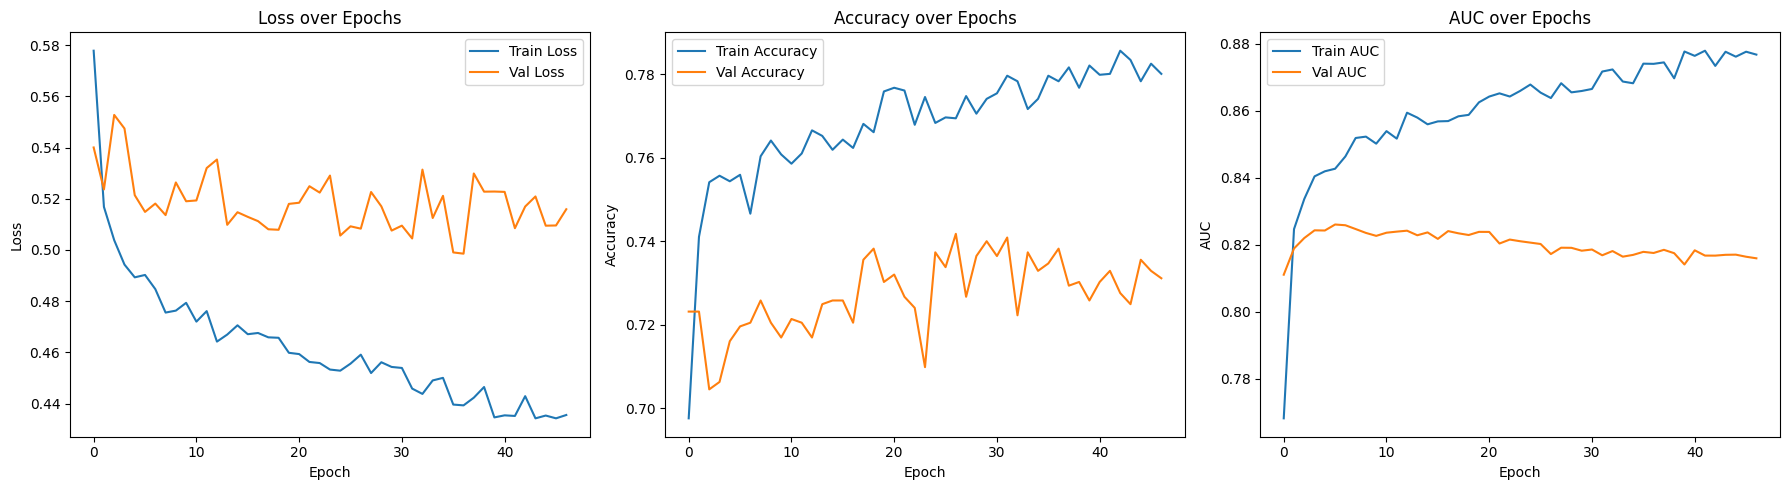

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC over Epochs')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()

plt.tight_layout()
plt.show()

In [19]:

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.50).astype(int)

test_loss, test_acc, test_auc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test Accuracy: 0.7559
Test AUC: 0.8317
Test Loss: 0.4778

Classification Report:

              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



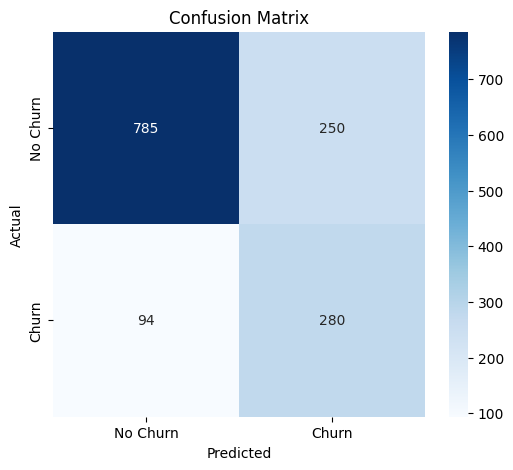

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

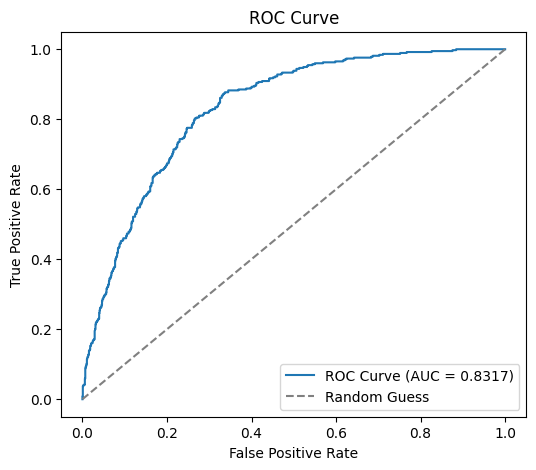

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {test_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [22]:

new_customer = pd.DataFrame({
    'SeniorCitizen': [0],
    'Partner': ['Yes'],
    'Dependents': ['No'],
    'tenure': [5],
    'PhoneService': ['Yes'],
    'MultipleLines': ['No'],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['Yes'],
    'StreamingMovies': ['Yes'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': ['Yes'],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [95.5],
    'TotalCharges': [477.5],
    'TotalServices': [4],
    'gender': ['Male']
})

new_customer

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalServices,gender
0,0,Yes,No,5,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,95.5,477.5,4,Male


In [23]:

new_customer = pd.get_dummies(new_customer, columns=['gender'], drop_first=False)

binary_map = {'Yes': 1, 'No': 0}
for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
    new_customer[col] = new_customer[col].map(binary_map)

multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
new_customer = pd.get_dummies(new_customer, columns=multi_cols, drop_first=True)

bool_cols = new_customer.select_dtypes(include='bool').columns
new_customer[bool_cols] = new_customer[bool_cols].astype(int)

new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

print(new_customer.shape)  
new_customer

(1, 32)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,TotalServices,gender_Female,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,5,1,1,95.5,477.5,4,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:

new_customer_scaled = scaler.transform(new_customer)

churn_prob = model.predict(new_customer_scaled)[0][0]
churn_pred = "Churn" if churn_prob > 0.5 else "No Churn"

print(f"Churn Probability: {churn_prob:.4f}")
print(f"Prediction: {churn_pred}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Churn Probability: 0.6630
Prediction: Churn


In [25]:
def predict_churn_batch(new_data, scaler, model, reference_columns):
    """
    new_data: DataFrame with customerID + raw feature columns (same as original CSV format)
    scaler: fitted StandardScaler from training
    model: trained Keras model
    reference_columns: X.columns (the exact column order/set used in training)
    """
    customer_ids = new_data['customerID'].copy()
    
    df_new = new_data.drop(columns=['customerID'])
    if 'TenureGroup' in df_new.columns:
        df_new = df_new.drop(columns=['TenureGroup'])
    if 'Churn' in df_new.columns:
        df_new = df_new.drop(columns=['Churn'])
    
    # Fix TotalCharges
    df_new['TotalCharges'] = pd.to_numeric(df_new['TotalCharges'], errors='coerce').fillna(0)
    
    # Gender one-hot
    df_new = pd.get_dummies(df_new, columns=['gender'], drop_first=False)
    
    # Binary label encoding
    binary_map = {'Yes': 1, 'No': 0}
    for col in ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
        df_new[col] = df_new[col].map(binary_map)
    
    # Multi-category one-hot
    multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                  'Contract', 'PaymentMethod']
    df_new = pd.get_dummies(df_new, columns=multi_cols, drop_first=True)
    
    # Bool to int
    bool_cols = df_new.select_dtypes(include='bool').columns
    df_new[bool_cols] = df_new[bool_cols].astype(int)
    
    # Align columns exactly to training columns
    df_new = df_new.reindex(columns=reference_columns, fill_value=0)
    
    # Scale
    df_new_scaled = scaler.transform(df_new)
    
    # Predict
    probs = model.predict(df_new_scaled, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    
    # Build result table
    result = pd.DataFrame({
        'customerID': customer_ids,
        'Churn_Probability': probs.round(4),
        'Predicted_Churn': ['Yes' if p == 1 else 'No' for p in preds]
    })
    
    return result

In [26]:
new_data = pd.read_csv('new_and_updated_customers.csv')
results = predict_churn_batch(new_data, scaler, model, X.columns)
print(results)

   customerID  Churn_Probability Predicted_Churn
0  7590-VHVEG             0.1430              No
1  5575-GNVDE             0.0248              No
2  3668-QPYBK             0.6715             Yes
3   CUST-2001             0.8083             Yes
4   CUST-2002             0.9048             Yes
5   CUST-2003             0.0618              No
6   CUST-2004             0.3501              No


In [27]:
results = predict_churn_batch(new_data, scaler, model, X.columns)
print(results)

   customerID  Churn_Probability Predicted_Churn
0  7590-VHVEG             0.1430              No
1  5575-GNVDE             0.0248              No
2  3668-QPYBK             0.6715             Yes
3   CUST-2001             0.8083             Yes
4   CUST-2002             0.9048             Yes
5   CUST-2003             0.0618              No
6   CUST-2004             0.3501              No
